# Dragon FHO — Exploratory Data Analysis
**Royal Draconic Conservatory | Regression Project**

This notebook explores the distribution of each variable and the relationships between predictors and the target (FHO), informing feature engineering and modelling choices.


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PALETTE = {"Dragon": "#c0392b", "Wyvern": "#2980b9", "Hydra": "#27ae60"}

df_raw = pd.read_csv("dragon_data (1).csv")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 7)


,SPC,AGE,MASS,WSP,HID,SPD,FHO
0,Wyvern,16,1304,4.0,4.83,4800,611
1,Dragon,2726,3693174,52.0,4.82,114400,1960
2,Dragon,377,154201,19.4,4.61,42680,1123
3,Hydra,169,40146,13.0,2.65,7800,706
4,Dragon,1571,1549315,39.6,1.49,87120,1441


## 1. Data Quality

In [2]:
print("=== Dtypes ===")
print(df_raw.dtypes)
print()
print("=== Null values ===")
print(df_raw.isnull().sum())
print()
print("=== Species counts (raw) ===")
print(df_raw["SPC"].value_counts())
print()
print("=== Negative numeric values ===")
num = df_raw.select_dtypes(include="number")
print((num < 0).sum())

=== Dtypes ===
SPC         str
AGE       int64
MASS      int64
WSP     float64
HID     float64
SPD       int64
FHO       int64
dtype: object

=== Null values ===
SPC     0
AGE     0
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64

=== Species counts (raw) ===
SPC
Hydra      214
Wyvern     183
Dragon     102
Wyvernn      1
Name: count, dtype: int64

=== Negative numeric values ===
AGE     1
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64


In [3]:
# Show the problematic rows
print("Negative AGE rows:")
print(df_raw[df_raw["AGE"] < 0])
print()
print("Typo species row:")
print(df_raw[~df_raw["SPC"].isin(["Dragon", "Wyvern", "Hydra"])])

Negative AGE rows:
        SPC  AGE    MASS   WSP  HID    SPD   FHO
328  Wyvern -481  223733  21.9  1.4  26280  1276

Typo species row:
         SPC   AGE    MASS   WSP   HID    SPD   FHO
228  Wyvernn  1229  745342  35.0  4.54  42000  1083


In [4]:
# Clean: fix typo, drop negative age
df = df_raw.copy()
df["SPC"] = df["SPC"].replace({"Wyvernn": "Wyvern"})
df = df[df["AGE"] >= 0].reset_index(drop=True)

print(f"Cleaned shape: {df.shape}")
print(df["SPC"].value_counts())

Cleaned shape: (499, 7)
SPC
Hydra     214
Wyvern    183
Dragon    102
Name: count, dtype: int64


## 2. Univariate Distributions

For each numeric variable we plot:
- A **histogram** to see the overall shape
- A **KDE** overlay to judge skewness
- A **log-scale histogram** where relevant to check if a log transform helps


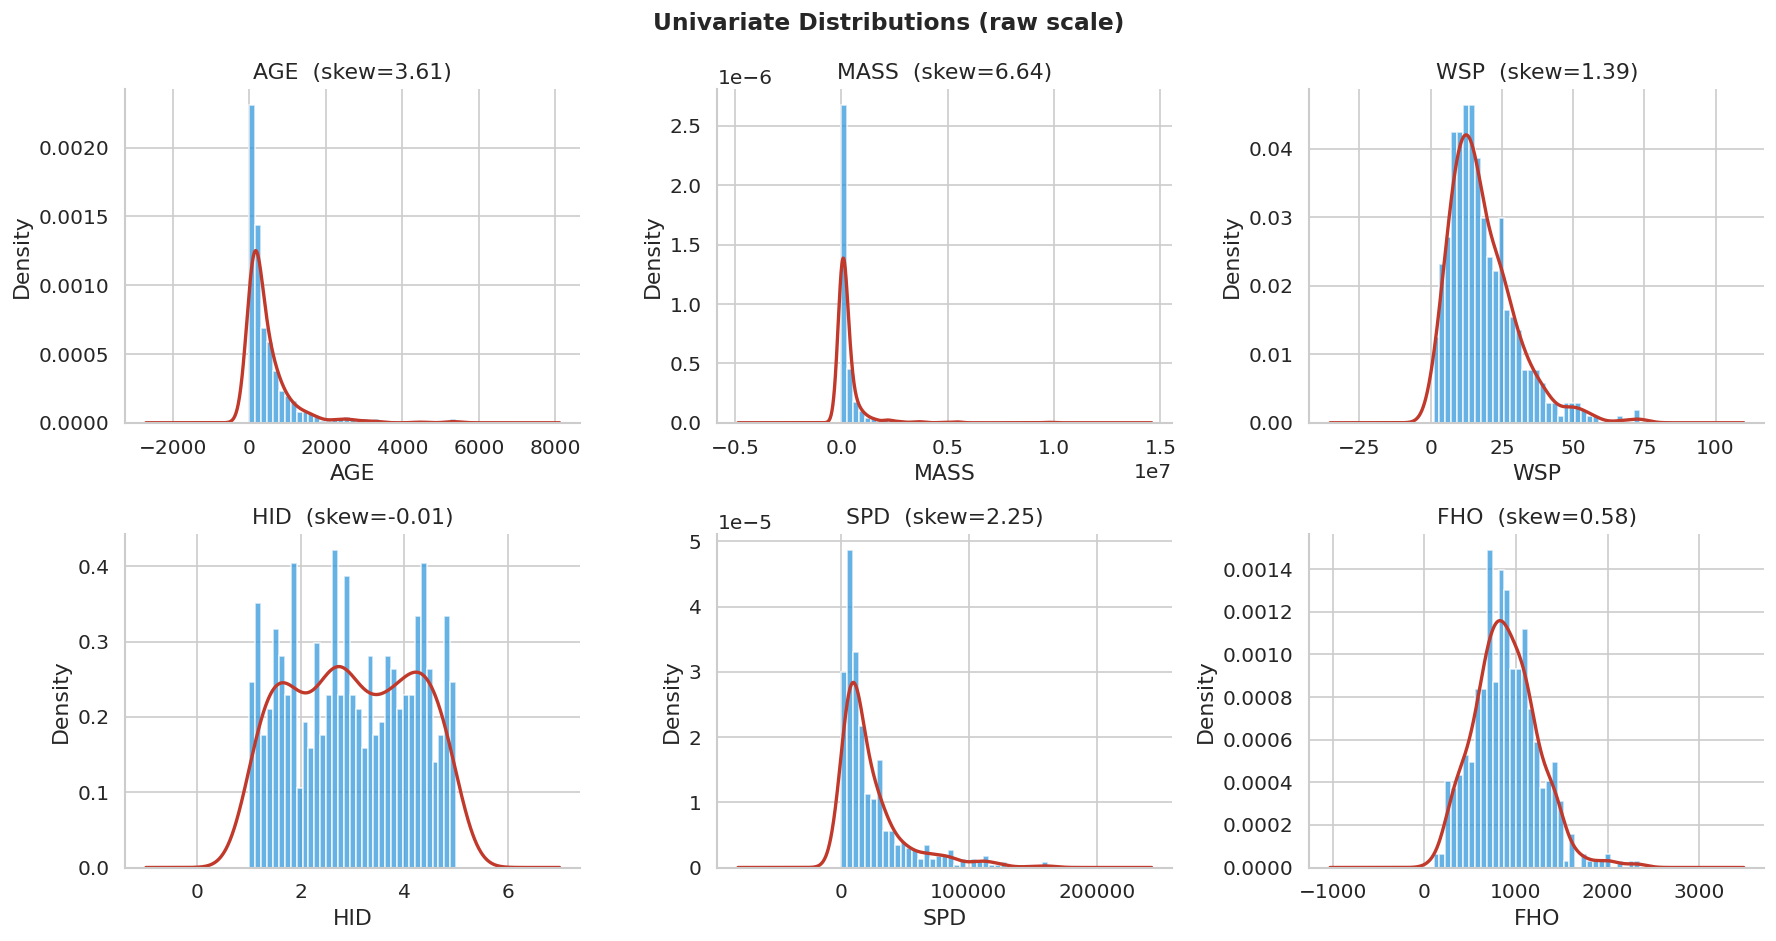

In [5]:
num_cols = ["AGE", "MASS", "WSP", "HID", "SPD", "FHO"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Univariate Distributions (raw scale)", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=35, color="#3498db", alpha=0.75, edgecolor="white", density=True)
    df[col].plot.kde(ax=ax, color="#c0392b", lw=2)
    skew = df[col].skew()
    ax.set_title(f"{col}  (skew={skew:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

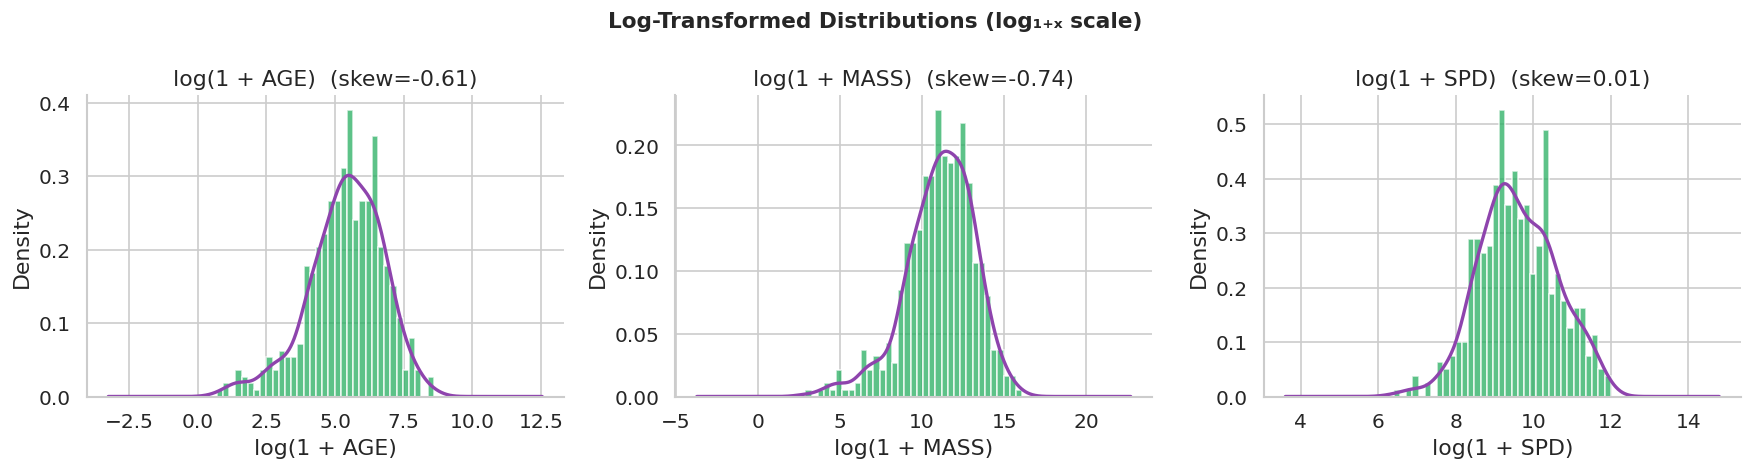

Log transform substantially reduces skewness in AGE, MASS, and SPD.


In [6]:
# Log-scale distributions for heavily skewed variables
skewed = ["AGE", "MASS", "SPD"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Log-Transformed Distributions (log₁₊ₓ scale)", fontsize=13, fontweight="bold")

for ax, col in zip(axes, skewed):
    log_vals = np.log1p(df[col])
    ax.hist(log_vals, bins=35, color="#27ae60", alpha=0.75, edgecolor="white", density=True)
    log_vals.plot.kde(ax=ax, color="#8e44ad", lw=2)
    skew = log_vals.skew()
    ax.set_title(f"log(1 + {col})  (skew={skew:.2f})")
    ax.set_xlabel(f"log(1 + {col})")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()
print("Log transform substantially reduces skewness in AGE, MASS, and SPD.")

In [7]:
# Summary statistics
df[num_cols].describe().round(2)

,AGE,MASS,WSP,HID,SPD,FHO
count,499.00,499.00,499.00,499.00,499.00,499.00
mean,463.36,309420.06,18.19,3.00,24152.87,893.48
std,642.51,752468.43,11.51,1.17,26595.34,350.41
min,1.00,17.00,1.00,1.01,600.00,100.00
25%,107.50,19237.50,10.40,1.92,7650.00,664.00
50%,242.00,79404.00,15.60,2.94,13860.00,869.00
75%,586.00,282925.00,24.20,4.04,29580.00,1107.00
max,5407.00,9729833.00,73.60,5.00,161920.00,2358.00


## 3. Target Variable: FHO

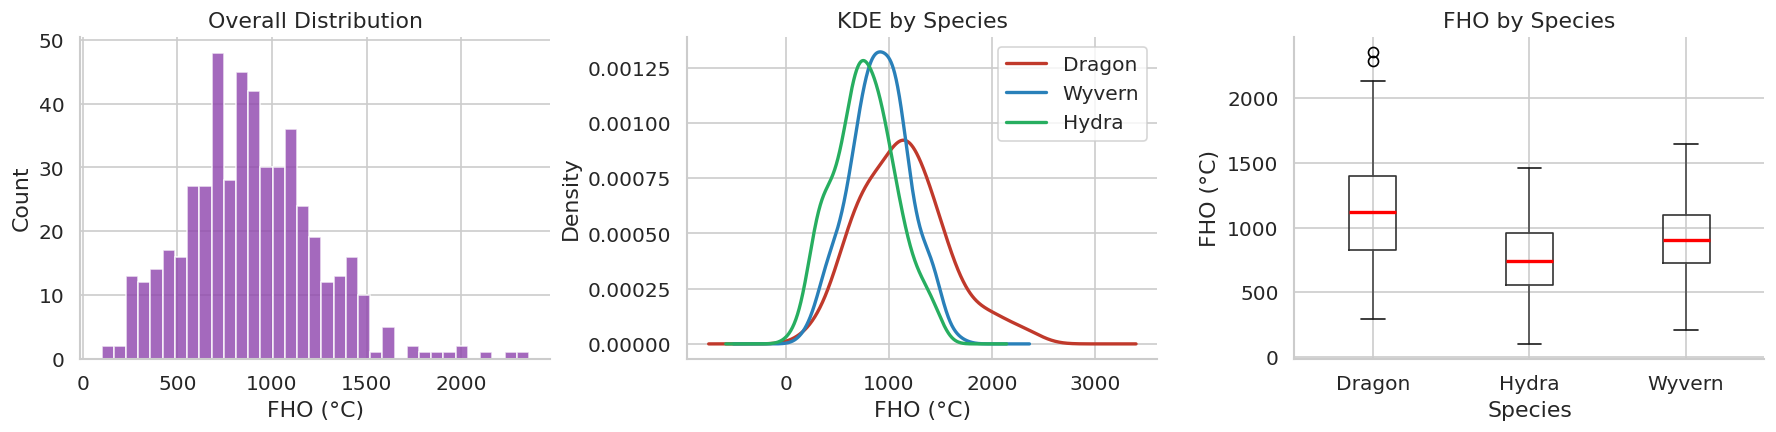

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("FHO Distribution", fontsize=13, fontweight="bold")

# Overall histogram
axes[0].hist(df["FHO"], bins=35, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("FHO (°C)"); axes[0].set_ylabel("Count")
axes[0].set_title("Overall Distribution")

# By species
for spc, col in PALETTE.items():
    sub = df[df["SPC"] == spc]["FHO"]
    sub.plot.kde(ax=axes[1], color=col, lw=2, label=spc)
axes[1].set_xlabel("FHO (°C)"); axes[1].set_title("KDE by Species")
axes[1].legend()

# Box plot by species
df.boxplot(column="FHO", by="SPC", ax=axes[2],
           boxprops=dict(color="#333"),
           medianprops=dict(color="red", lw=2))
axes[2].set_title("FHO by Species")
axes[2].set_xlabel("Species"); axes[2].set_ylabel("FHO (°C)")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [9]:
print("=== FHO mean by species ===")
print(df.groupby("SPC")["FHO"].agg(["mean","median","std"]).round(1))

=== FHO mean by species ===
          mean  median    std
SPC                          
Dragon  1136.8  1123.0  423.0
Hydra    764.0   741.0  297.6
Wyvern   909.2   905.0  282.7


## 4. Species — Physical Characteristics

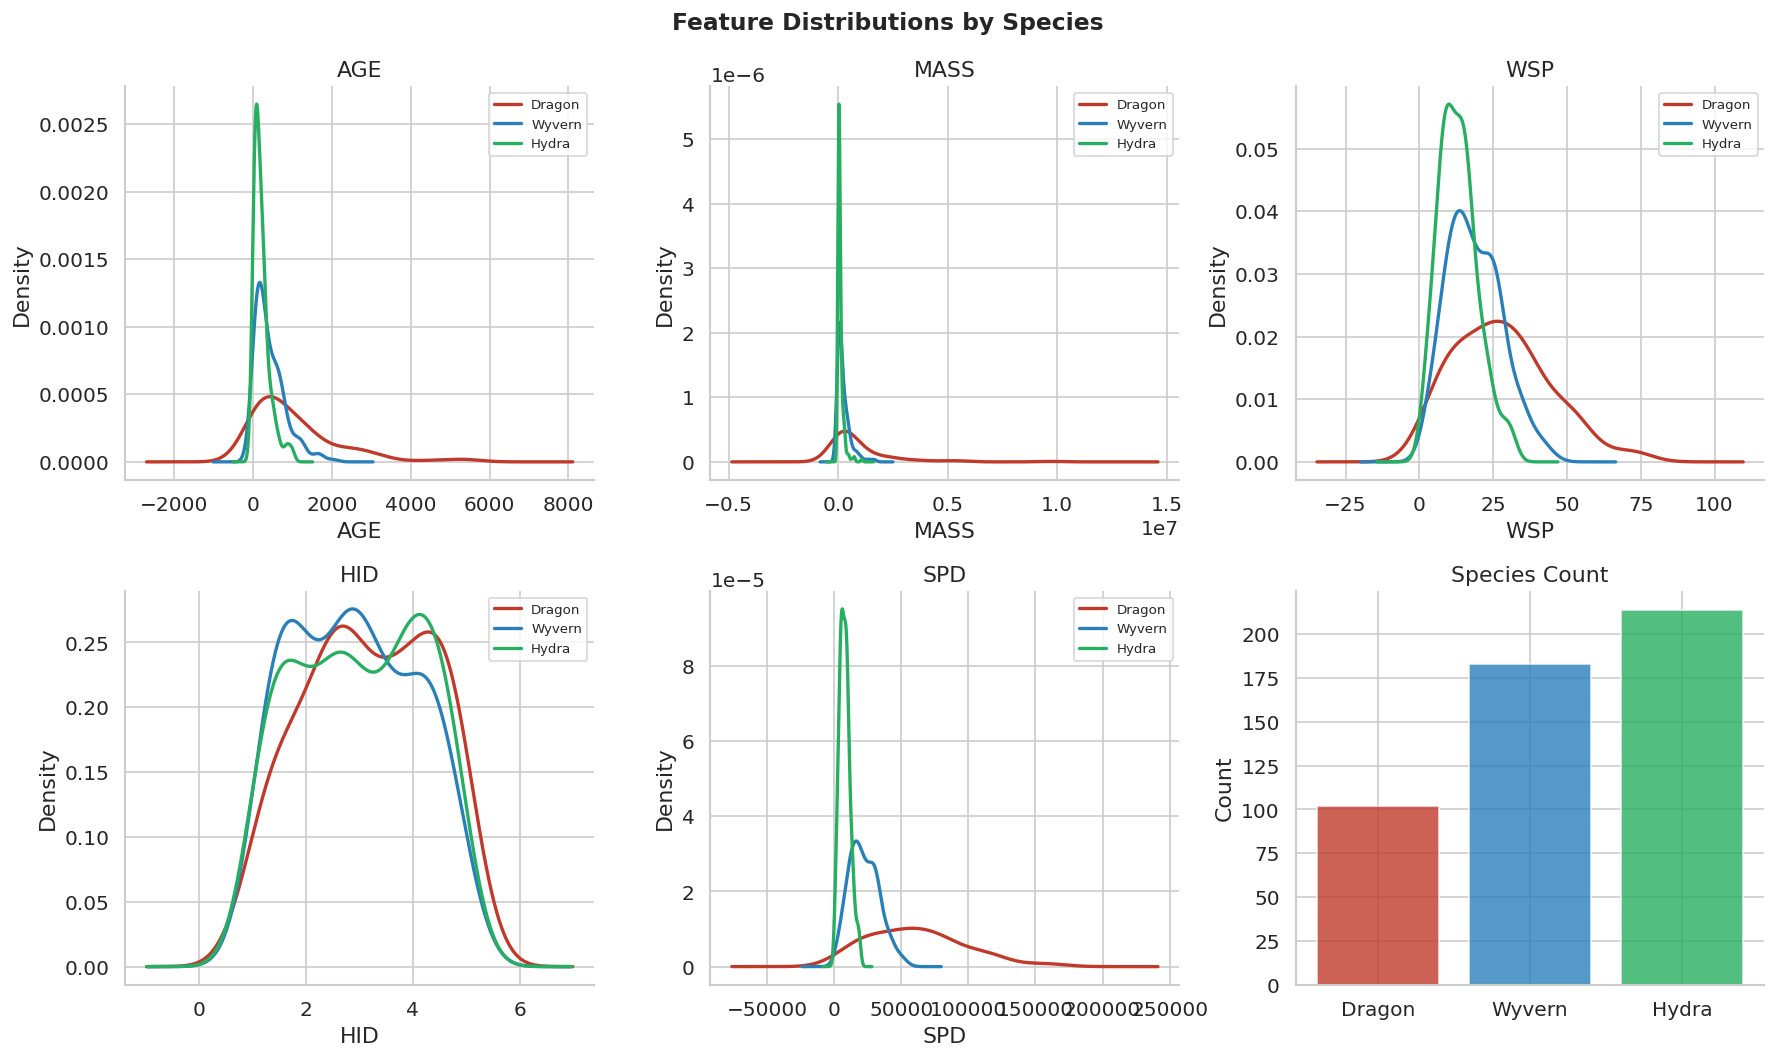

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold")

features = ["AGE", "MASS", "WSP", "HID", "SPD"]
for ax, feat in zip(axes.flat, features):
    for spc, col in PALETTE.items():
        df[df["SPC"] == spc][feat].plot.kde(ax=ax, color=col, lw=2, label=spc)
    ax.set_title(feat); ax.set_xlabel(feat); ax.legend(fontsize=8)

# Species count bar
axes[1][2].bar(PALETTE.keys(), [len(df[df["SPC"]==s]) for s in PALETTE],
               color=list(PALETTE.values()), alpha=0.8, edgecolor="white")
axes[1][2].set_title("Species Count"); axes[1][2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5. Predictor vs FHO Relationships

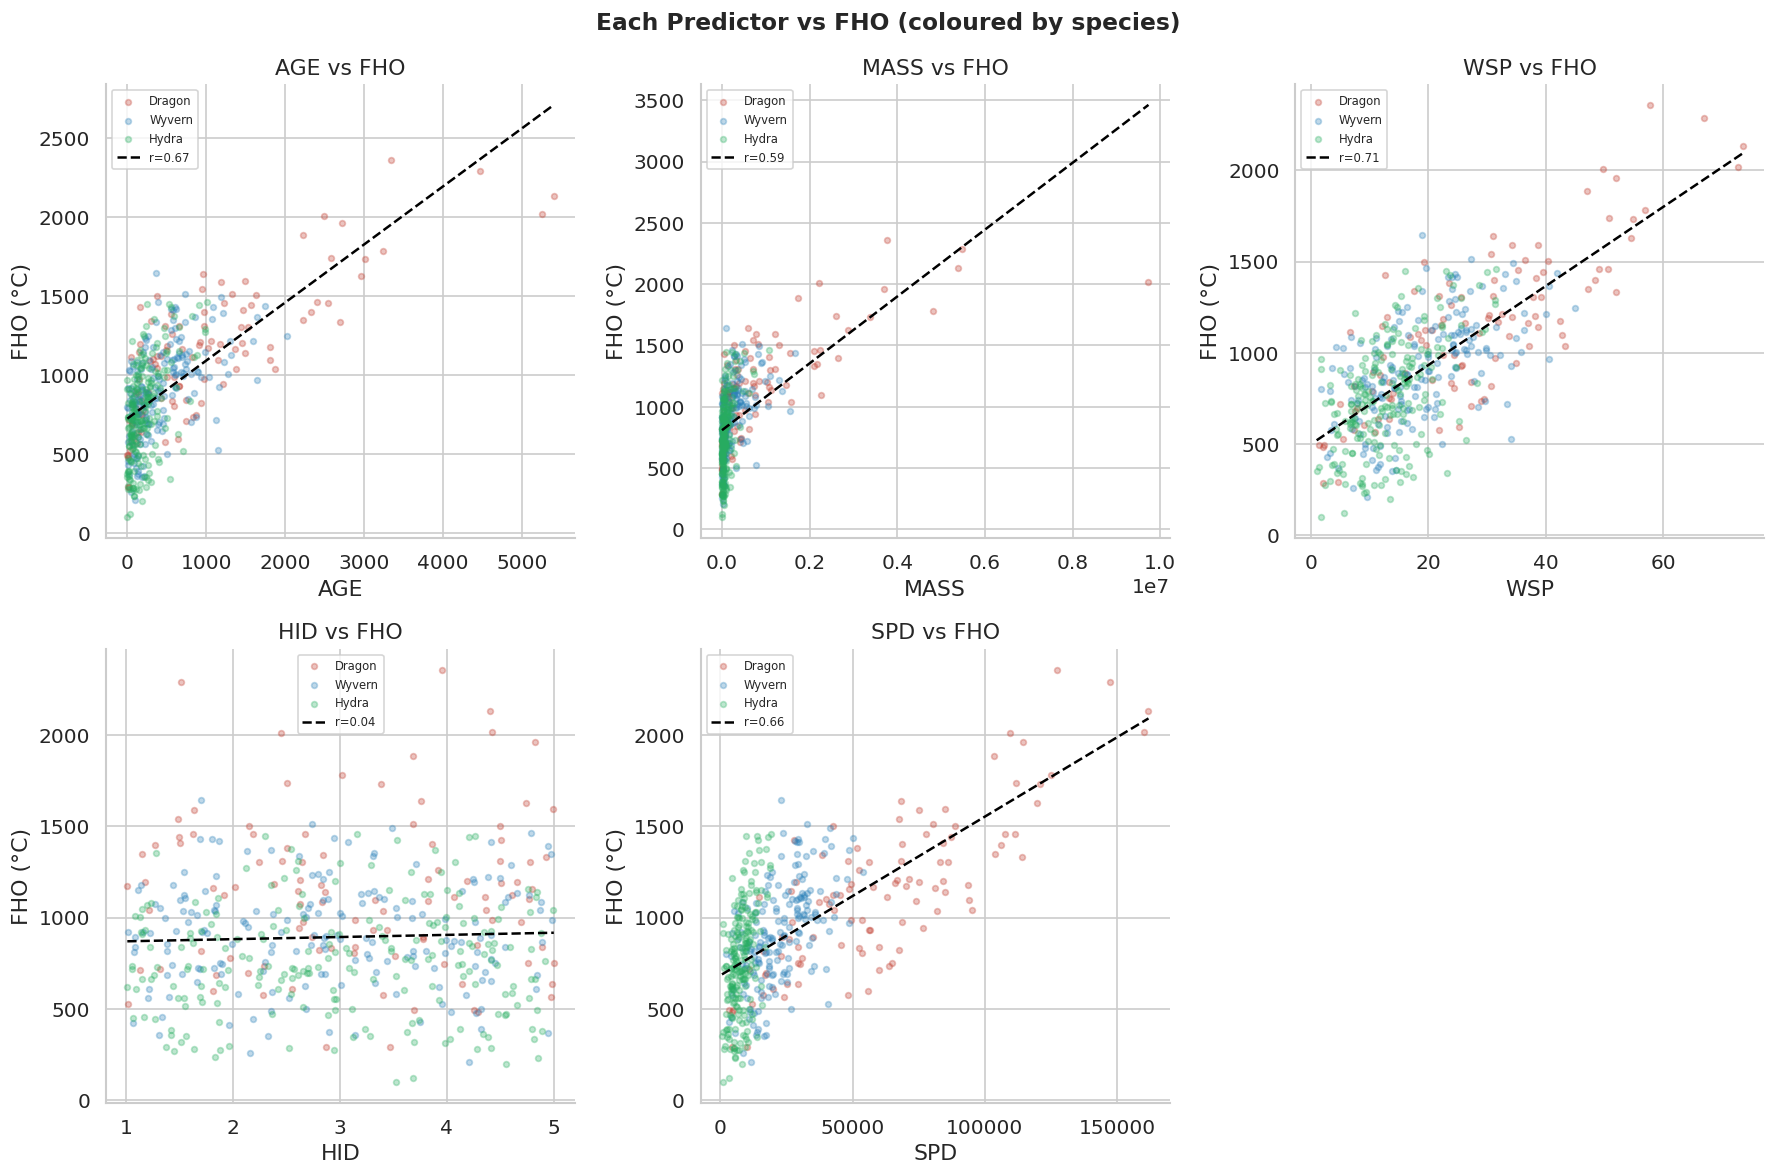

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Each Predictor vs FHO (coloured by species)", fontsize=14, fontweight="bold")

predictors = ["AGE", "MASS", "WSP", "HID", "SPD"]
for ax, feat in zip(axes.flat, predictors):
    for spc, col in PALETTE.items():
        sub = df[df["SPC"] == spc]
        ax.scatter(sub[feat], sub["FHO"], color=col, alpha=0.3, s=12, label=spc)
    # Overall OLS line
    m, b, r, p, _ = stats.linregress(df[feat], df["FHO"])
    x_range = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(x_range, m * x_range + b, color="black", lw=1.5, ls="--", label=f"r={r:.2f}")
    ax.set_xlabel(feat); ax.set_ylabel("FHO (°C)"); ax.set_title(f"{feat} vs FHO")
    ax.legend(fontsize=7)

axes[1][2].axis("off")
plt.tight_layout()
plt.show()

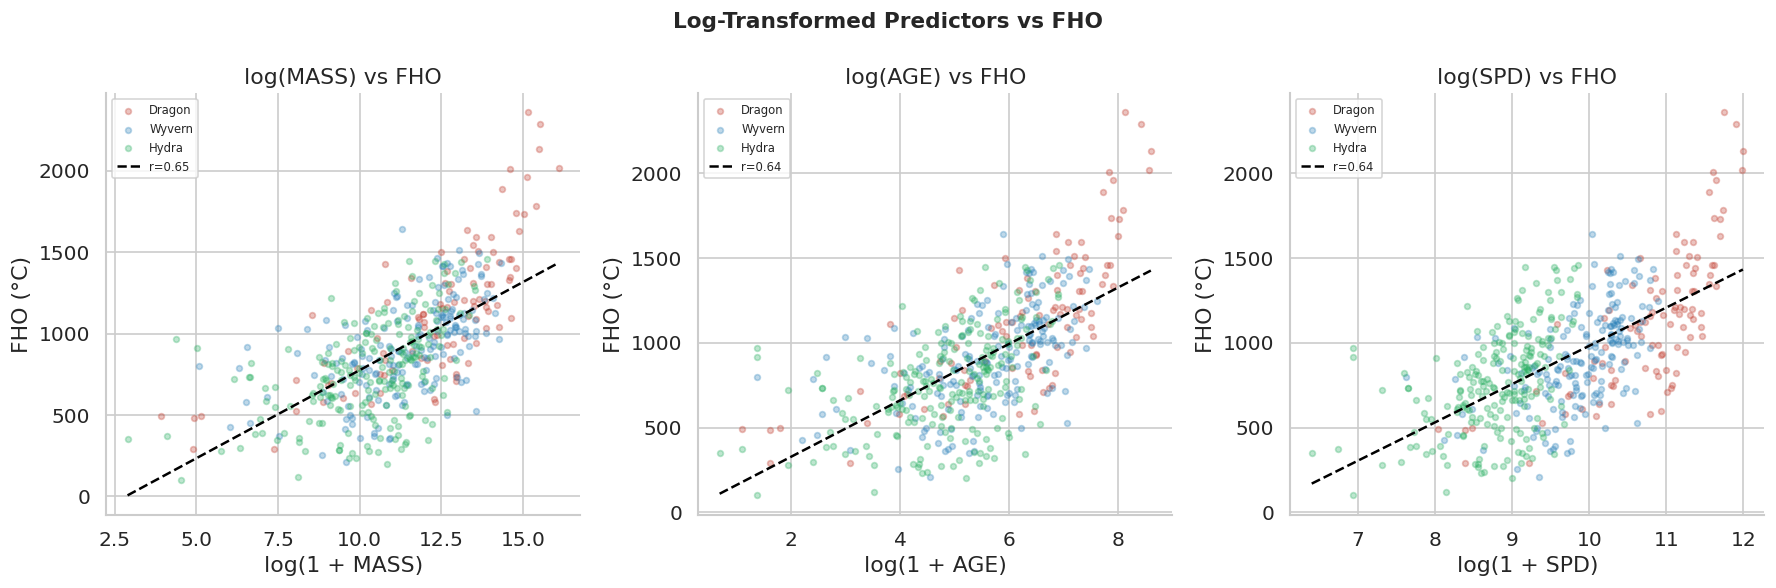

Log transforms improve linearity — log(MASS) and log(AGE) show tighter, more linear relationships with FHO.


In [12]:
# Same plots on log scale for skewed variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Log-Transformed Predictors vs FHO", fontsize=13, fontweight="bold")

for ax, feat in zip(axes, ["MASS", "AGE", "SPD"]):
    log_x = np.log1p(df[feat])
    for spc, col in PALETTE.items():
        mask = df["SPC"] == spc
        ax.scatter(log_x[mask], df["FHO"][mask], color=col, alpha=0.3, s=12, label=spc)
    m, b, r, p, _ = stats.linregress(log_x, df["FHO"])
    x_range = np.linspace(log_x.min(), log_x.max(), 200)
    ax.plot(x_range, m * x_range + b, color="black", lw=1.5, ls="--", label=f"r={r:.2f}")
    ax.set_xlabel(f"log(1 + {feat})"); ax.set_ylabel("FHO (°C)")
    ax.set_title(f"log({feat}) vs FHO")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print("Log transforms improve linearity — log(MASS) and log(AGE) show tighter, more linear relationships with FHO.")

## 6. Correlation Matrix

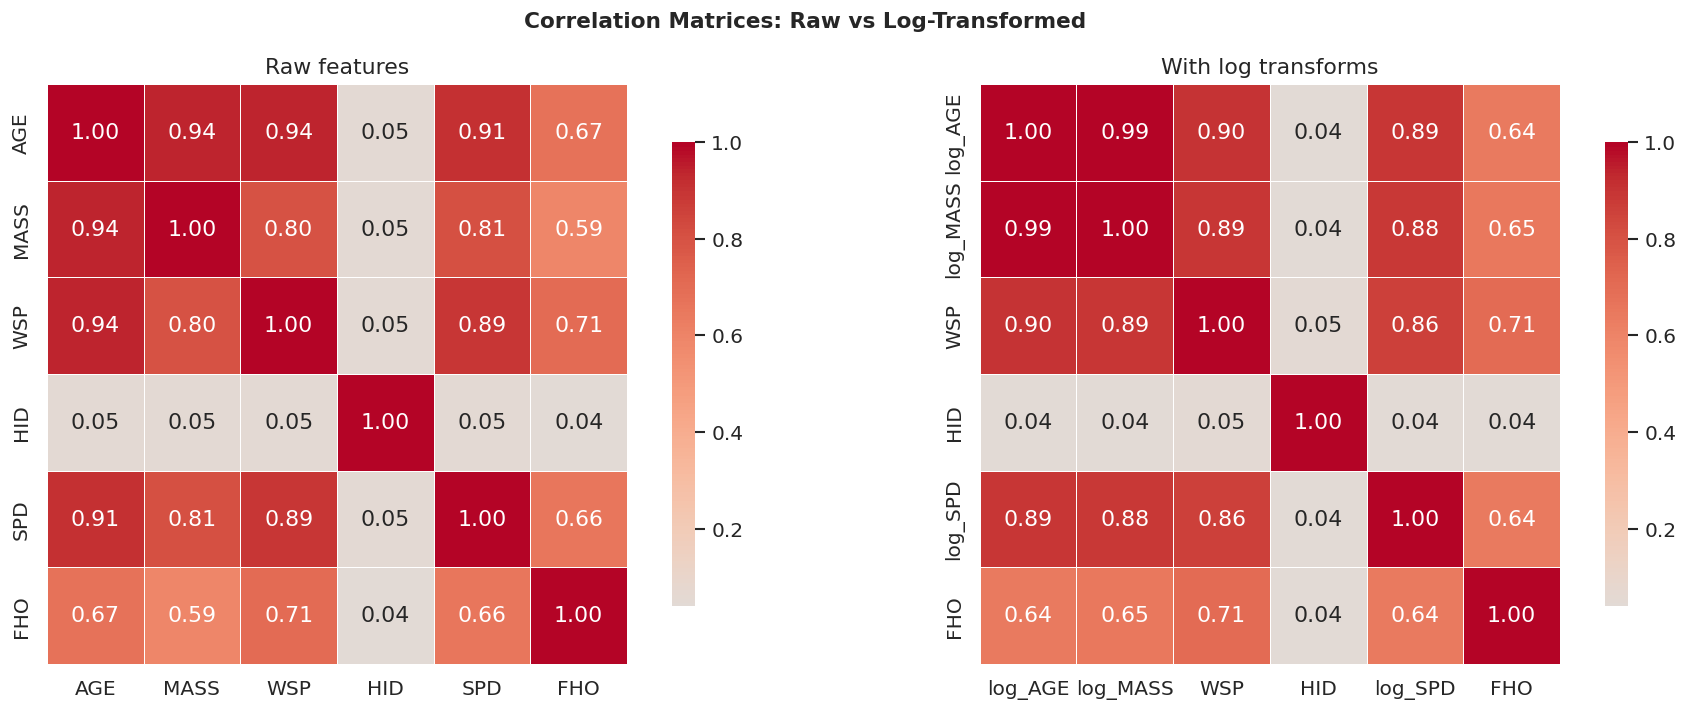

In [13]:
corr_df = df[["AGE","MASS","WSP","HID","SPD","FHO"]].copy()
corr_df["log_AGE"]  = np.log1p(df["AGE"])
corr_df["log_MASS"] = np.log1p(df["MASS"])
corr_df["log_SPD"]  = np.log1p(df["SPD"])

corr = corr_df.corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation Matrices: Raw vs Log-Transformed", fontsize=13, fontweight="bold")

raw_cols = ["AGE","MASS","WSP","HID","SPD","FHO"]
log_cols = ["log_AGE","log_MASS","WSP","HID","log_SPD","FHO"]

for ax, cols, title in zip(axes, [raw_cols, log_cols], ["Raw features", "With log transforms"]):
    sns.heatmap(corr.loc[cols, cols], annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, ax=ax, linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7. Pairplot

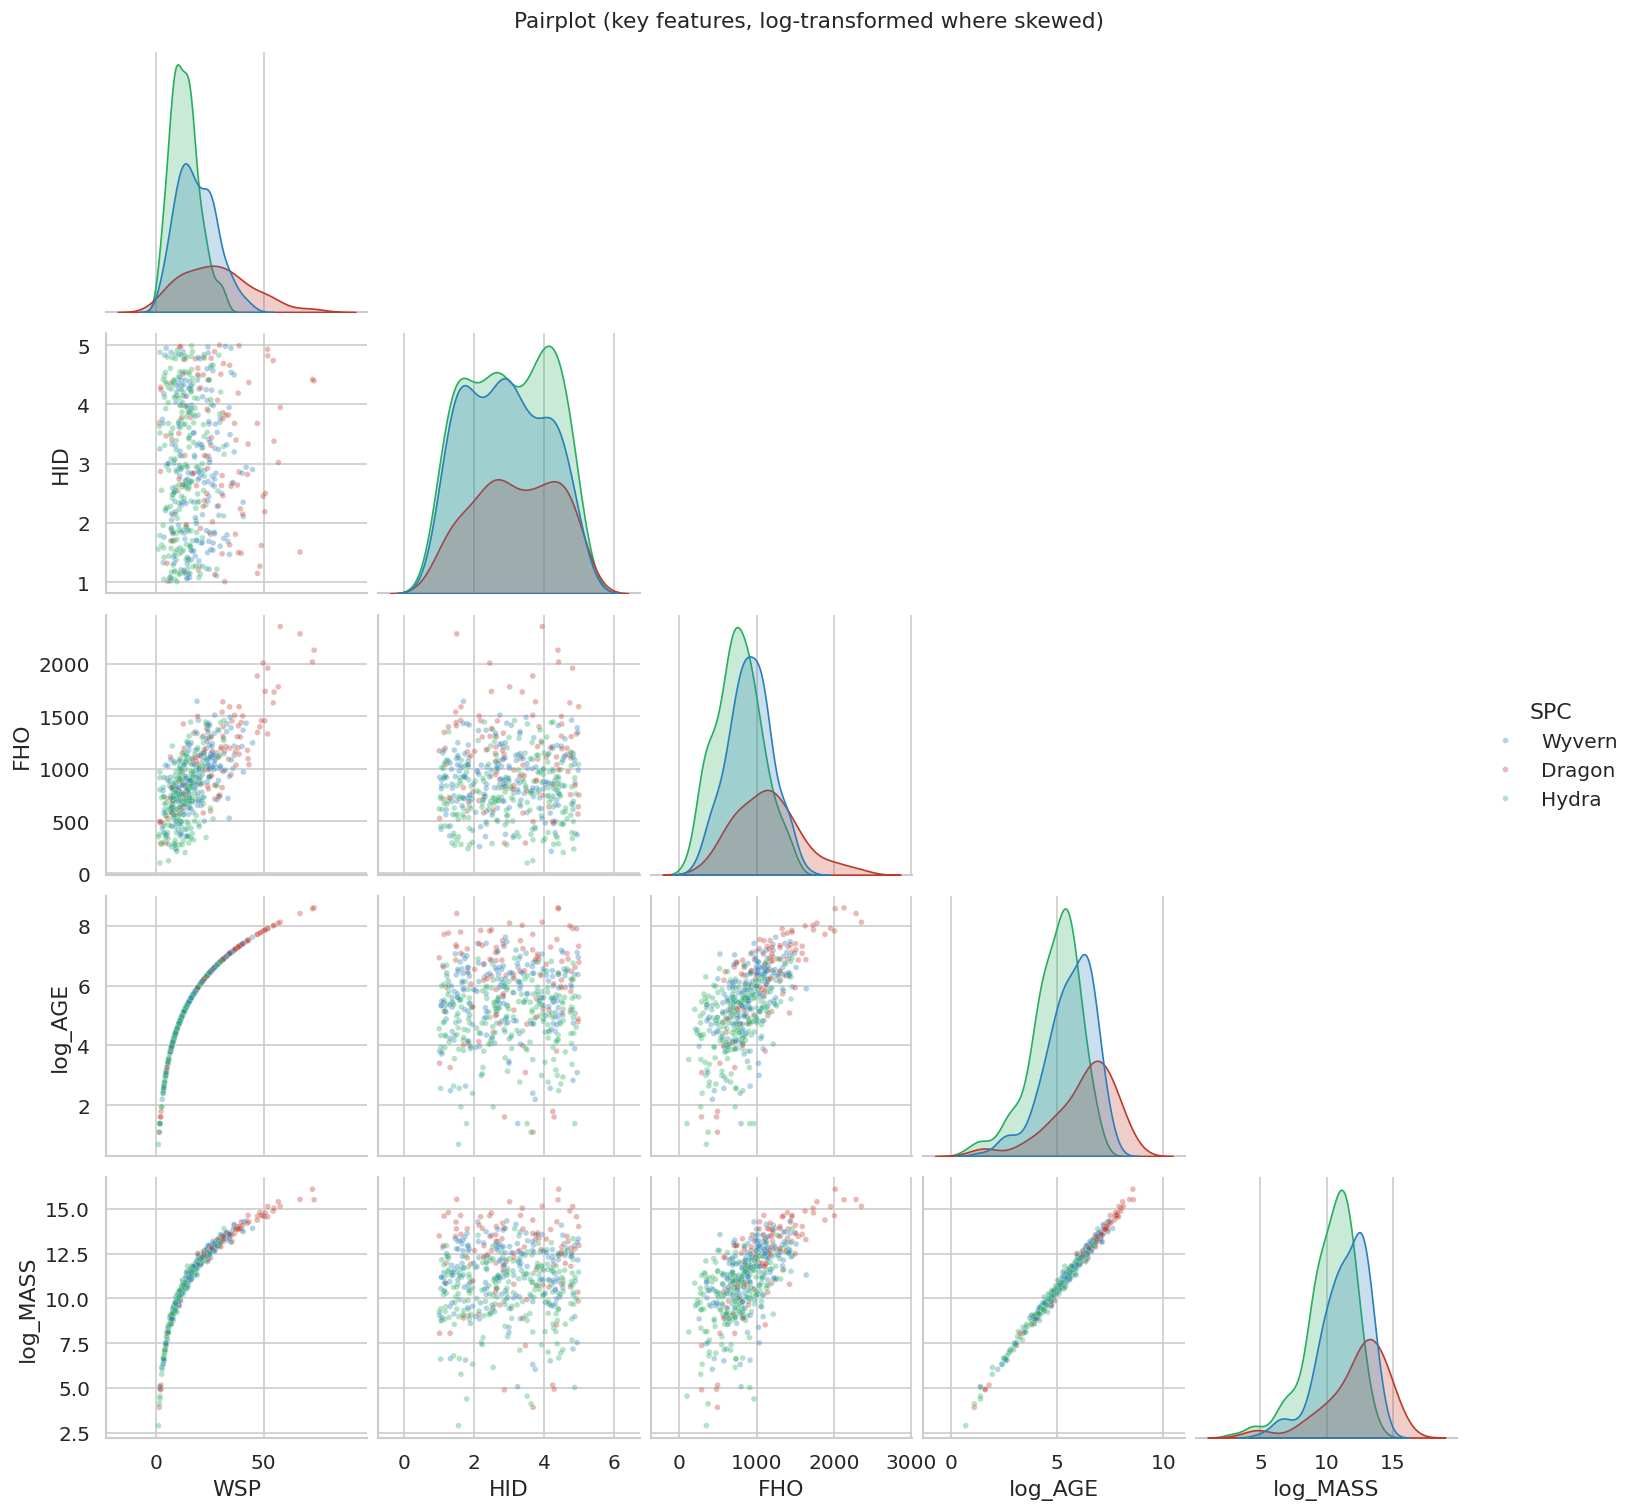

In [14]:
pair_df = df[["WSP","HID","FHO","SPC"]].copy()
pair_df["log_AGE"]  = np.log1p(df["AGE"])
pair_df["log_MASS"] = np.log1p(df["MASS"])

g = sns.pairplot(pair_df, hue="SPC", palette=PALETTE,
                 plot_kws={"alpha": 0.35, "s": 12},
                 diag_kind="kde", corner=True)
g.figure.suptitle("Pairplot (key features, log-transformed where skewed)", y=1.01, fontsize=13)
plt.show()

## 8. Multicollinearity Check

High correlation between predictors (multicollinearity) can destabilise coefficients. We check this with Variance Inflation Factor (VIF).


In [15]:

from sklearn.linear_model import LinearRegression

def vif(X_df):
    """Manual VIF: for each feature, regress it on all others and compute 1/(1-R²)."""
    vifs = []
    cols = list(X_df.columns)
    for i, col in enumerate(cols):
        others = [c for c in cols if c != col]
        m = LinearRegression()
        m.fit(X_df[others], X_df[col])
        r2 = m.score(X_df[others], X_df[col])
        vifs.append({"Feature": col, "VIF": round(1 / (1 - r2 + 1e-10), 2)})
    return pd.DataFrame(vifs).sort_values("VIF", ascending=False)

vif_df = df[["WSP","MASS","AGE","HID","SPD"]].copy()
vif_df["log_MASS"] = np.log1p(df["MASS"])
vif_df["log_AGE"]  = np.log1p(df["AGE"])
vif_df["log_SPD"]  = np.log1p(df["SPD"])

for label, feats in [
    ("Raw",             ["AGE","MASS","WSP","HID","SPD"]),
    ("Log-transformed", ["log_AGE","log_MASS","WSP","HID","log_SPD"]),
]:
    print(f"=== VIF ({label}) ===")
    print(vif(vif_df[feats]).to_string(index=False))
    print()


=== VIF (Raw) ===
Feature   VIF
    AGE 45.37
    WSP 14.56
   MASS 13.89
    SPD  6.42
    HID  1.00

=== VIF (Log-transformed) ===
 Feature    VIF
 log_AGE 120.75
log_MASS 101.84
     WSP   6.32
 log_SPD   5.16
     HID   1.00



## 9. Outlier Analysis

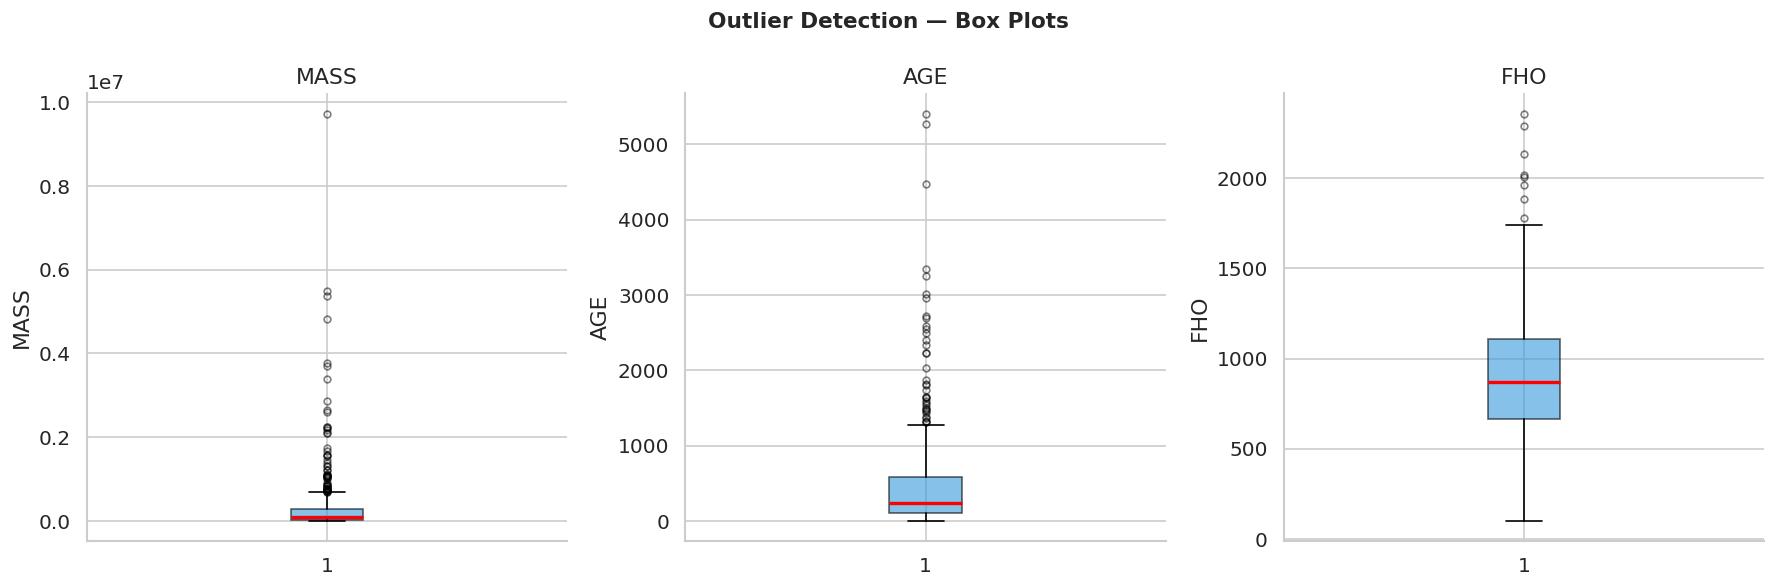

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Outlier Detection — Box Plots", fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["MASS", "AGE", "FHO"]):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#3498db", alpha=0.6),
               medianprops=dict(color="red", lw=2),
               flierprops=dict(marker="o", markersize=4, alpha=0.5, color="#e74c3c"))
    ax.set_title(col); ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [17]:
# Z-score outliers in FHO
z_scores = np.abs(stats.zscore(df["FHO"]))
outliers = df[z_scores > 3]
print(f"FHO outliers (|z| > 3): {len(outliers)}")
print(outliers[["SPC","AGE","MASS","WSP","FHO"]])

FHO outliers (|z| > 3): 6
        SPC   AGE     MASS   WSP   FHO
1    Dragon  2726  3693174  52.0  1960
160  Dragon  5407  5374972  73.6  2132
169  Dragon  2492  2214540  49.8  2009
205  Dragon  4475  5486433  67.0  2288
351  Dragon  3345  3760660  57.8  2358
455  Dragon  5263  9729833  72.8  2019


## 10. Interaction Term Preview

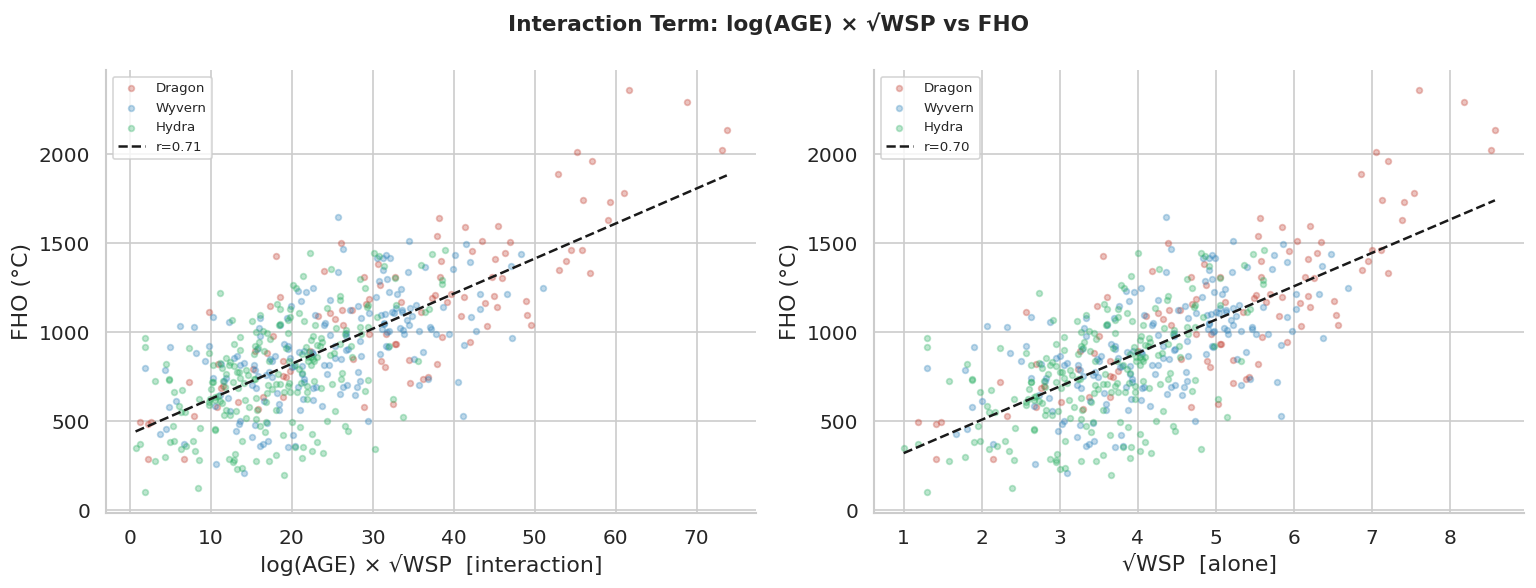

In [18]:
df["log_AGE"]  = np.log1p(df["AGE"])
df["sqrt_WSP"] = np.sqrt(df["WSP"])
df["AGE_x_WSP"] = df["log_AGE"] * df["sqrt_WSP"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Interaction Term: log(AGE) × √WSP vs FHO", fontsize=13, fontweight="bold")

for ax, (feat, label) in zip(axes, [
    ("AGE_x_WSP", "log(AGE) × √WSP  [interaction]"),
    ("sqrt_WSP",  "√WSP  [alone]"),
]):
    for spc, col in PALETTE.items():
        sub = df[df["SPC"] == spc]
        ax.scatter(sub[feat], sub["FHO"], color=col, alpha=0.3, s=12, label=spc)
    m, b, r, *_ = stats.linregress(df[feat], df["FHO"])
    x_r = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(x_r, m*x_r + b, "k--", lw=1.5, label=f"r={r:.2f}")
    ax.set_xlabel(label); ax.set_ylabel("FHO (°C)"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Key EDA Findings

| Finding | Implication |
|---------|-------------|
| MASS, AGE, SPD are heavily right-skewed (skew > 5) | Apply log transforms before modelling |
| WSP has the strongest linear correlation with FHO (r ≈ 0.71) | WSP should be in every model |
| log(AGE) and log(MASS) correlate better with FHO than raw versions | Log transforms improve linearity |
| Dragons > Wyverns > Hydras in median FHO | Species is informative but largely mediated by size |
| MASS and WSP are highly correlated (~0.97) | Risk of multicollinearity; monitor VIF |
| AGE × WSP interaction shows tighter relationship with FHO than either alone | Include interaction term in feature engineering |
| HID has near-zero correlation with FHO | Low priority predictor |
| SPD correlates with FHO but also with WSP | May be redundant — check VIF |
